# CAPM Analysis — versão ajustada

Esta versão corrige alguns pontos conceituais importantes do notebook original:

- usa **retornos mensais em excesso** (ação e mercado menos taxa livre de risco mensal);
- converte a **taxa livre de risco anual para mensal**;
- calcula o beta por **covariância** e por **regressão OLS**;
- anualiza o retorno esperado com **capitalização composta**;
- adiciona checagens de erro e organização melhor do código.


Também inclui uma célula de instalação compatível com Jupyter e uma taxa livre de risco anual mais realista para o contexto brasileiro.

In [8]:
%pip install yfinance pandas numpy matplotlib statsmodels --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")

In [10]:
# Parâmetros principais
RISK_FREE_RATE_ANNUAL = 0.1451  # 14,51% a.a. (ex.: CDI, março/2026)
MONTHS_IN_YEAR = 12

# Conversão da taxa livre de risco anual para taxa mensal equivalente
RISK_FREE_RATE_MONTHLY = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / MONTHS_IN_YEAR) - 1

print(f"Taxa livre de risco anual: {RISK_FREE_RATE_ANNUAL:.2%}")
print(f"Taxa livre de risco mensal equivalente: {RISK_FREE_RATE_MONTHLY:.4%}")

Taxa livre de risco anual: 14.51%
Taxa livre de risco mensal equivalente: 1.1355%


In [11]:
class CAPM:
    """Modelo CAPM com retornos mensais e regressão OLS."""

    def __init__(self, stock_ticker, market_ticker, start_date, end_date, rf_annual=0.1451):
        self.stock_ticker = stock_ticker
        self.market_ticker = market_ticker
        self.start_date = start_date
        self.end_date = end_date
        self.rf_annual = rf_annual
        self.rf_monthly = (1 + rf_annual) ** (1 / 12) - 1

        self.prices = None
        self.data = None
        self.beta_cov = None
        self.alpha = None
        self.beta = None
        self.r_squared = None
        self.expected_return_monthly = None
        self.expected_return_annual = None
        self.model = None

    def download_data(self):
        tickers = [self.stock_ticker, self.market_ticker]
        raw = yf.download(
            tickers,
            start=self.start_date,
            end=self.end_date,
            auto_adjust=True,
            progress=False
        )

        if raw.empty:
            raise ValueError("Nenhum dado foi baixado. Verifique os tickers e o período.")

        if isinstance(raw.columns, pd.MultiIndex):
            if "Close" not in raw.columns.get_level_values(0):
                raise ValueError("A coluna 'Close' não foi encontrada nos dados baixados.")
            prices = raw["Close"].copy()
        else:
            prices = raw[["Close"]].copy()
            prices.columns = [self.stock_ticker]

        # garante que ambas as colunas existem
        missing = [t for t in tickers if t not in prices.columns]
        if missing:
            raise ValueError(f"Ticker(s) ausente(s) nos dados: {missing}")

        self.prices = prices[[self.stock_ticker, self.market_ticker]].dropna()
        return self.prices

    def prepare_data(self):
        if self.prices is None:
            self.download_data()

        monthly_prices = self.prices.resample("ME").last().dropna()

        data = pd.DataFrame({
            "stock_price": monthly_prices[self.stock_ticker],
            "market_price": monthly_prices[self.market_ticker],
        })

        # retornos logarítmicos mensais
        data["stock_return"] = np.log(data["stock_price"] / data["stock_price"].shift(1))
        data["market_return"] = np.log(data["market_price"] / data["market_price"].shift(1))

        data = data.dropna().copy()

        # CAPM formal: usar retornos em excesso
        data["stock_excess"] = data["stock_return"] - self.rf_monthly
        data["market_excess"] = data["market_return"] - self.rf_monthly

        self.data = data
        return self.data

    def calculate_beta_covariance(self):
        if self.data is None:
            self.prepare_data()

        cov_matrix = np.cov(self.data["stock_excess"], self.data["market_excess"])
        self.beta_cov = cov_matrix[0, 1] / cov_matrix[1, 1]
        return self.beta_cov

    def run_regression(self):
        if self.data is None:
            self.prepare_data()

        X = sm.add_constant(self.data["market_excess"])
        y = self.data["stock_excess"]

        self.model = sm.OLS(y, X).fit()
        self.alpha = self.model.params["const"]
        self.beta = self.model.params["market_excess"]
        self.r_squared = self.model.rsquared

        # retorno esperado via CAPM
        market_premium = self.data["market_return"].mean() - self.rf_monthly
        self.expected_return_monthly = self.rf_monthly + self.beta * market_premium
        self.expected_return_annual = (1 + self.expected_return_monthly) ** 12 - 1

        return self.model

    def summary(self):
        if self.model is None:
            self.run_regression()

        summary_dict = {
            "beta_covariance": self.beta_cov if self.beta_cov is not None else self.calculate_beta_covariance(),
            "alpha_monthly": self.alpha,
            "beta_regression": self.beta,
            "r_squared": self.r_squared,
            "expected_return_monthly": self.expected_return_monthly,
            "expected_return_annual": self.expected_return_annual,
        }
        return pd.Series(summary_dict)

    def plot_regression(self):
        if self.model is None:
            self.run_regression()

        x = self.data["market_excess"]
        y = self.data["stock_excess"]

        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = self.alpha + self.beta * x_line

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.scatter(x, y, alpha=0.7, label="Retornos mensais em excesso")
        ax.plot(x_line, y_line, color="red", linewidth=2, label="Reta CAPM estimada")

        ax.set_title(f"CAPM: {self.stock_ticker} vs {self.market_ticker}")
        ax.set_xlabel("Retorno do mercado em excesso")
        ax.set_ylabel("Retorno da ação em excesso")
        ax.legend()
        plt.show()

    def print_results(self):
        if self.model is None:
            self.run_regression()

        beta_cov = self.calculate_beta_covariance()

        print(f"Ação analisada: {self.stock_ticker}")
        print(f"Benchmark de mercado: {self.market_ticker}")
        print(f"Taxa livre de risco anual: {self.rf_annual:.2%}")
        print(f"Taxa livre de risco mensal equivalente: {self.rf_monthly:.4%}")
        print("-" * 60)
        print(f"Beta (covariância): {beta_cov:.4f}")
        print(f"Alpha mensal: {self.alpha:.4f}")
        print(f"Beta (regressão OLS): {self.beta:.4f}")
        print(f"R²: {self.r_squared:.4f}")
        print(f"Retorno esperado mensal (CAPM): {self.expected_return_monthly:.4%}")
        print(f"Retorno esperado anual (CAPM): {self.expected_return_annual:.2%}")

## Exemplo de uso

No exemplo abaixo, a ação analisada é a **VALE3** e o benchmark de mercado é o **Ibovespa** (`^BVSP`), usado como proxy da carteira de mercado.  
Na prática, o CAPM teórico supõe a carteira de mercado total, mas em aplicações empíricas costuma-se usar um índice amplo.


In [12]:
capm = CAPM(
    stock_ticker="VALE3.SA",
    market_ticker="^BVSP",
    start_date="2010-01-01",
    end_date="2025-12-31",
    rf_annual=RISK_FREE_RATE_ANNUAL
)

capm.download_data()
capm.prepare_data()
capm.run_regression()
capm.print_results()

capm.summary()

Ação analisada: VALE3.SA
Benchmark de mercado: ^BVSP
Taxa livre de risco anual: 14.51%
Taxa livre de risco mensal equivalente: 1.1355%
------------------------------------------------------------
Beta (covariância): 0.7919
Alpha mensal: 0.0008
Beta (regressão OLS): 0.7919
R²: 0.2537
Retorno esperado mensal (CAPM): 0.6101%
Retorno esperado anual (CAPM): 7.57%


beta_covariance            0.791942
alpha_monthly              0.000847
beta_regression            0.791942
r_squared                  0.253745
expected_return_monthly    0.006101
expected_return_annual     0.075718
dtype: float64

In [13]:
# Resumo estatístico completo da regressão
capm.model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           stock_excess   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     64.26
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.10e-13
Time:                        19:28:34   Log-Likelihood:                 204.71
No. Observations:                 191   AIC:                            -405.4
Df Residuals:                     189   BIC:                            -398.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0008      0.006      0.140      0.889      -0.011       0.013
market_excess     0.7919      0.099      8.017      0.000       0.597       0.987
==============================================================================
Omnibus:                        8.826   Durbin-Watson:                   2.175
Prob(Omnibus):                  0.012   Jarque-Bera (JB):               17.103
Skew:                           0.084   Prob(JB):                     0.000193
Kurtosis:                       4.456   Cond. No.                         16.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

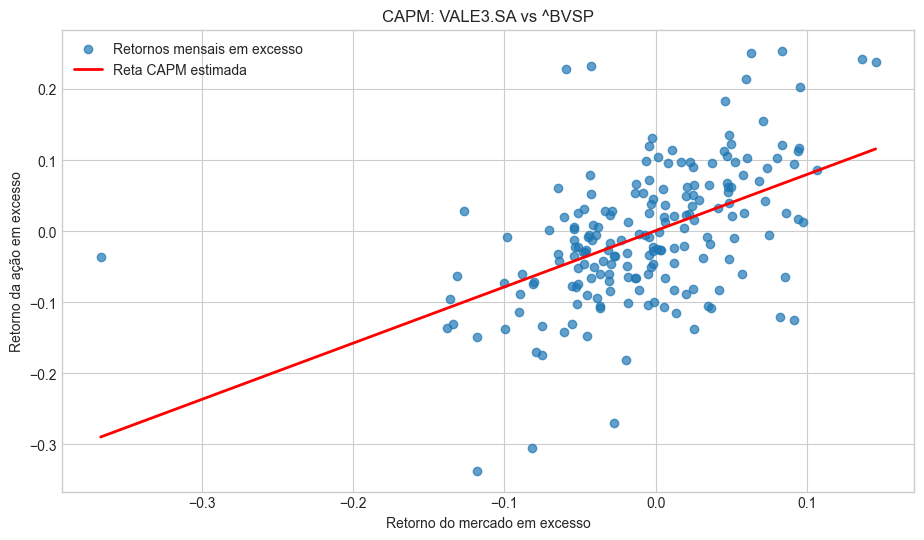

In [14]:
capm.plot_regression()